# 과제 1 - SVM 회귀


In [1]:
!pip install numpy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [2]:
# 데이터 로드
california_housing = fetch_california_housing(as_frame=True)
X, y = california_housing.data, california_housing.target

# 위, 경도 데이터 열 삭제
X = X.drop('Latitude', axis = 1)
X = X.drop('Longitude', axis = 1)

# 데이터 스케일
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


In [12]:
# 모델 생성
svr = SVR(epsilon = 0.01)

# 모델 훈련
svr.fit(X_train, y_train)


SVR(epsilon=0.01)

In [13]:
# 예측
y_pred_scaled = svr.predict(X_test)

# 스케일 복원
y_test = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)



Mean Squared Error: 0.45835891638101384
R-squared: 0.650216898699582


In [5]:
print(y_pred)

[[0.75859982]
 [1.36685297]
 [3.78972841]
 ...
 [4.62704727]
 [1.07361099]
 [1.75725154]]


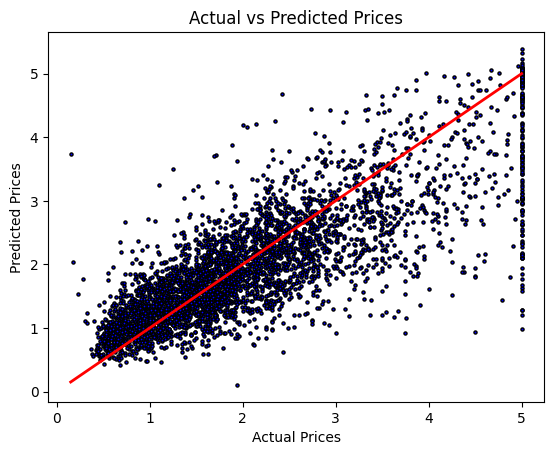

In [6]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

epsilon :  0.01
mse :  0.45835891638101384
r2 :  0.650216898699582
epsilon :  0.11
mse :  0.45652378936764193
r2 :  0.6516173218070576
epsilon :  0.21000000000000002
mse :  0.4534803882890743
r2 :  0.6539398036650902
epsilon :  0.31000000000000005
mse :  0.45084687339752283
r2 :  0.6559494929569681
epsilon :  0.41000000000000003
mse :  0.4494263722547324
r2 :  0.6570335065484327
epsilon :  0.51
mse :  0.4520026273914677
r2 :  0.6550675133512603
epsilon :  0.6100000000000001
mse :  0.45962737693282796
r2 :  0.6492489104051817
epsilon :  0.7100000000000001
mse :  0.475600387122171
r2 :  0.6370595783305608
epsilon :  0.81
mse :  0.4978714581680902
r2 :  0.6200640666882216
epsilon :  0.91
mse :  0.5314210151232156
r2 :  0.5944617108495409


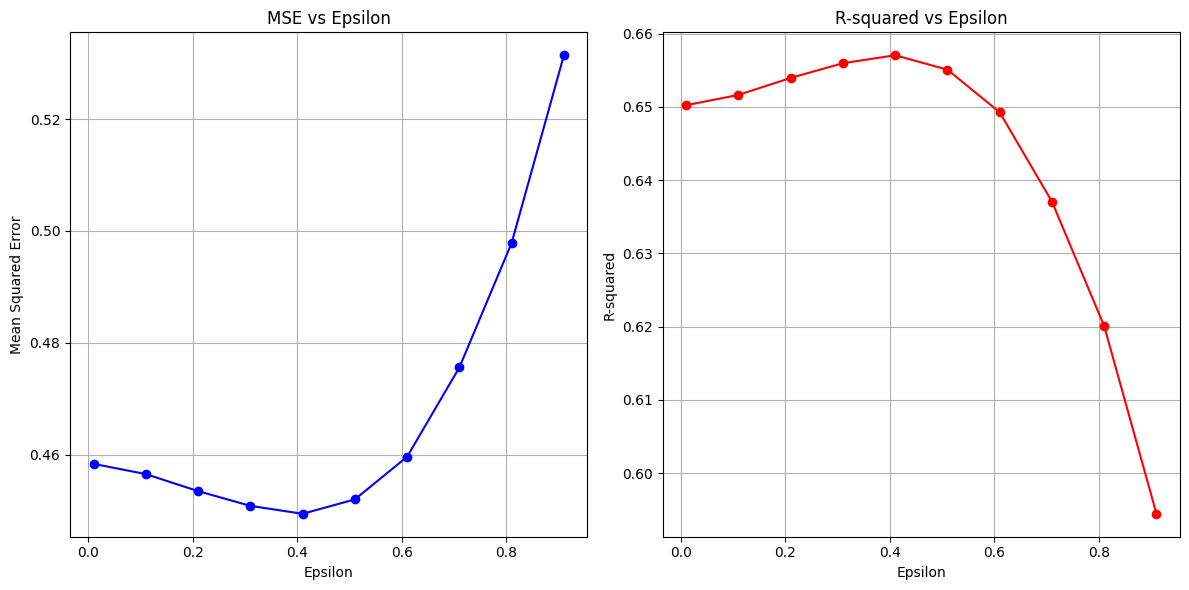

Best epsilon (highest R-squared): 0.41000000000000003


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# epsilon 값을 0.01부터 1까지 0.01씩 증가
epsilons = np.arange(0.01, 1, 0.1)
mse_values = []
r2_values = []

# epsilon 값에 대해 모델 훈련 및 성능 평가
for epsilon in epsilons:
    # 모델 생성
    your_svr = SVR(epsilon=epsilon)

    # 모델 훈련
    your_svr.fit(X_train, y_train)

    # 예측
    y_pred_scaled = your_svr.predict(X_test)

    # 스케일 복원
    y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))
    y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    # 성능 평가
    mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
    r2 = r2_score(y_test_rescaled, y_pred_rescaled)

    mse_values.append(mse)
    r2_values.append(r2)
    print("epsilon : ",epsilon)
    print("mse : ",mse)
    print("r2 : ",r2)

# 그래프 그리기
plt.figure(figsize=(12, 6))

# MSE 그래프
plt.subplot(1, 2, 1)
plt.plot(epsilons, mse_values, marker='o', color='b', label='Mean Squared Error')
plt.xlabel('Epsilon')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs Epsilon')
plt.grid(True)

# R-squared 그래프
plt.subplot(1, 2, 2)
plt.plot(epsilons, r2_values, marker='o', color='r', label='R-squared')
plt.xlabel('Epsilon')
plt.ylabel('R-squared')
plt.title('R-squared vs Epsilon')
plt.grid(True)

# 그래프 표시
plt.tight_layout()
plt.show()

# 최적의 epsilon 찾기 (R-squared가 가장 높은 값)
best_epsilon = epsilons[np.argmax(r2_values)]
print(f"Best epsilon (highest R-squared): {best_epsilon}")

과제1-1 분석 코드 및 설명
epsilons값을 0.01부터 0.91까지 0.1씩 증가시키는 방법으로 성능지표의 변화를 그래프로 표현해보았다. 0.01씩 증가시키고 싶었지만 시간이 너무 오래 걸려 비교적 performance는 낮더라도 0.1씩 증가시키는 방법으로 성능지표에 변화를 확인해보았다.
epsilon은 허용범위로 본인은 당연히 허용범위를 늘리면 늘릴수록 결정계수는 높아지고 mse는 감소하는 경향을 보일 것이라 예상을 하였다.
그래프를 보면 0.41에서 증가 감소 경향이 바뀌고 성능지표가 가장 좋은것이라는 것을 판단할 수 있다. 생각해 본 결과 epsilon이 작을수록 민감한 데이터에 대해 더 잘 반응하나 과적합이 발생할 수 있고 epsilon이 클수록 허용범위를 넓힐수록 더 robust해지고 일반화 성능이 좋아진다고 기대 할 수 있으나 모델의 유연성이 떨어져서 데이터의 변화를 잘 반영하지 못하는 것 같다. 즉 작은 epsilon 값은 과적합을 초래할 수 있고, 너무 큰 epsilon 값은 모델을 너무 단순화시켜 성능을 떨어질 수 있는 것 같다. 즉 0.01부터 0.91까지 0.1씩 epsilon값을 증가시킨 결과 0.41이 본인 모델 기준에서 최적의 성능지표가 나온다.

In [ ]:
# Todo

# 과제 1-2 : SVM 분류

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [5]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
print("y==0 개수 : " ,(y==0).sum())
print("y==1 개수 : " ,(y==1).sum())
print("y==2 개수 : " ,(y==2).sum())

y==0 개수 :  50
y==1 개수 :  50
y==2 개수 :  50


레이블 0,1,2 사이 불균형이 없기에 가중치를 따로 부여 할 필요는 없어보인다.


## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

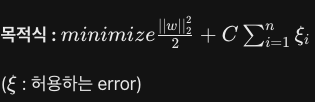


In [30]:
# 다양한 trade-off 파라미터 C 값 설정
#C_values = [0.1, , , , , , , ,] # Todo
#C_values=[0.1]
# epsilon 값을 0.01부터 1까지 0.01씩 증가
C_values = np.arange(0.01, 1, 0.01)
train_accuracies = []
test_accuracies = []

for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C)

    # 모델 훈련
    svc.fit(X_train, y_train)

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

--------------------------------------------------
C=0.02:
Training Accuracy: 0.9
Testing Accuracy: 0.9
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.67      0.80         9
           2       0.79      1.00      0.88        11

    accuracy                           0.90        30
   macro avg       0.93      0.89      0.89        30
weighted avg       0.92      0.90      0.90        30

--------------------

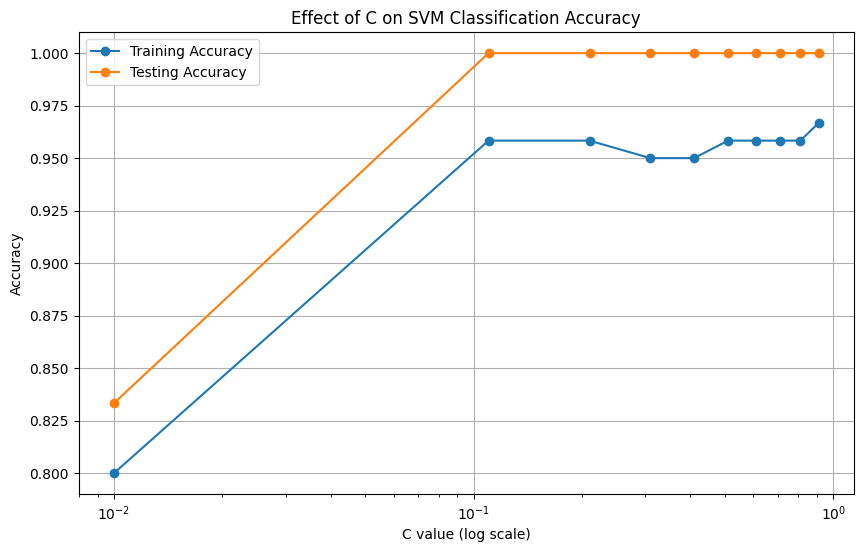

In [29]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()


과제1-2 분석 코드 및 설명 - 과제 1-1과 같은 방법을 사용
 C_values값을 0.01부터 1까지 0.01씩 증가시키는 방법으로 성능지표의 변화를 그래프로 표현해보았다. training accuaracy 부분에서는 0.11 이후 1로 모두 예측을 성공하고 이후에도 모두 1이다. testing accuracy부분에서 0.11에서
 Training Accuracy: 0.9583333333333334 값을 보이고 값을 증가할 수록 어느정도에 변화는 있으나 미미하다고 볼 수 있다. 1까지에 범위에서는 1에서 testing accuaracy가 비록 가장 우수하다고 볼 수 있더라도 그 범위에 변화가 미미하고 오차범위를 줄여서 더 좋은 값을 예측을 위해 본인이라면 c값을 1이 아닌 0.11로 설정할 것 이다.